In [1]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download("prasoonkottarathil/btcinusd")

# Move to custom directory
target_dir = "./dataset"
os.makedirs(target_dir, exist_ok=True)
shutil.copytree(path, target_dir, dirs_exist_ok=True)

print("Dataset copied to:", target_dir)

c:\Users\youss\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 80.2M/80.2M [00:28<00:00, 2.91MB/s]

Extracting files...


Dataset copied to: ./dataset


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
from scipy import stats as sp_stats

warnings.filterwarnings('ignore')

In [30]:
raw = pd.read_csv("dataset\BTC-Daily.csv")
raw.head()

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
1,1646006400,2022-02-28 00:00:00,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2,1645920000,2022-02-27 00:00:00,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
3,1645833600,2022-02-26 00:00:00,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
4,1645747200,2022-02-25 00:00:00,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


In [31]:
# Handdle whitespaces in columns name
raw.columns = [c.strip() for c in raw.columns]

In [32]:
print(f'Loaded {len(raw):,} rows × {len(raw.columns)} columns')
print(f'Columns: {list(raw.columns)}')
raw.head(5)

Loaded 2,651 rows × 9 columns
Columns: ['unix', 'date', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC', 'Volume USD']


,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
1,1646006400,2022-02-28 00:00:00,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2,1645920000,2022-02-27 00:00:00,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
3,1645833600,2022-02-26 00:00:00,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
4,1645747200,2022-02-25 00:00:00,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


In [33]:
print(raw.dtypes) # Raw datatpes

print('\n=== MISSING VALUES ===')
missing = raw.isnull().sum()
print(missing)

print('\n=== DUPLICATE ROWS ===')
dups = raw.duplicated().sum()
print(f'{dups} duplicate rows detected.')

print('\n=== SAMPLE VALUES ===')
raw.sample(5)

unix            int64
date           object
symbol         object
open          float64
high          float64
low           float64
close         float64
Volume BTC    float64
Volume USD    float64
dtype: object

=== MISSING VALUES ===
unix          0
date          0
symbol        0
open          0
high          0
low           0
close         0
Volume BTC    0
Volume USD    0
dtype: int64

=== DUPLICATE ROWS ===
0 duplicate rows detected.

=== SAMPLE VALUES ===


,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
2023,1471305600,2016-08-16 00:00:00,BTC/USD,564.20,579.80,563.00,577.53,2.737496e+06,4.786520e+03
397,1611792000,2021-01-28 00:00:00,BTC/USD,30427.34,33870.58,29899.99,33484.87,1.787936e+04,5.986879e+08
1125,1548892800,2019-01-31 00:00:00,BTC/USD,3438.00,3474.20,3392.60,3413.11,5.951818e+03,2.031421e+07
1240,1538956800,2018-10-08 00:00:00,BTC/USD,6574.15,6656.63,6541.06,6604.75,4.079044e+03,2.694107e+07
1508,1515801600,2018-01-13 00:00:00,BTC/USD,13781.41,14619.10,13781.41,14197.78,1.065957e+08,7.488990e+03


## Handling Columns

In [34]:
df = raw.copy()

# Handle date column

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'] = df['date'].dt.tz_localize(None)   # strip timezone if any
df['date'] = df['date'].dt.normalize()          # strip time -> pure date

bad_dates = df['date'].isna().sum()
print(f'Date parse: {bad_dates} unparseable values (will be dropped)')

Date parse: 0 unparseable values (will be dropped)


In [35]:
# Drop Duplicate date rows
n_before = len(df)
df = df.drop_duplicates(subset=['date'])
print(f'Duplicate dates removed: {n_before - len(df)}')

Duplicate dates removed: 0


In [36]:
# Drop rows where date or close price is null
n_before = len(df)
df = df.dropna(subset=['date', 'close'])
print(f'Rows dropped (null date or close): {n_before - len(df)}')

Rows dropped (null date or close): 0


In [37]:
df = df.sort_values('date').reset_index(drop=True)

print(f'\nAfter cleaning:')
print(f'  Rows       : {len(df):,}')
print(f'  Date range : {df['date'].min().date()}  to  {df['date'].max().date()}')
df.head(5)


After cleaning:
  Rows       : 2,651
  Date range : 2014-11-28  to  2022-03-01


,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1417132800,2014-11-28,BTC/USD,363.59,381.34,360.57,376.28,3220878.18,8617.15
1,1417219200,2014-11-29,BTC/USD,376.42,386.60,372.25,376.72,2746157.05,7245.19
2,1417305600,2014-11-30,BTC/USD,376.57,381.99,373.32,373.34,1145566.61,3046.33
3,1417392000,2014-12-01,BTC/USD,376.40,382.31,373.03,378.39,2520662.37,6660.56
4,1417478400,2014-12-02,BTC/USD,378.39,382.86,375.23,379.25,2593576.46,6832.53


In [38]:
# Any missing days (data provider gaps) are forward-filled from the previous day.
full_range = pd.date_range(start=df['date'].min(),
                           end=df['date'].max(),
                           freq='D')

df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

n_gaps = df['close'].isna().sum()
print(f'Calendar gaps detected: {n_gaps} missing days in the data')

if n_gaps > 0:
    fill_cols = [c for c in ['open', 'high', 'low', 'close',
                              'Volume BTC', 'Volume USD', 'unix']
                 if c in df.columns]
    df[fill_cols] = df[fill_cols].ffill()
    print(f'  Forward-filled: {fill_cols}')

df = df.reset_index()   # bring DATE_COL back as a regular column
print(f'\nFinal row count after gap-fill: {len(df):,}')
df[['date', 'close']].tail(5)

Calendar gaps detected: 0 missing days in the data

Final row count after gap-fill: 2,651


,date,close
2646,2022-02-25,39231.64
2647,2022-02-26,39146.66
2648,2022-02-27,37712.68
2649,2022-02-28,43178.98
2650,2022-03-01,43185.48


## Detect Outlier

In [39]:
price = df['close']
Q1, Q3 = price.quantile(0.25), price.quantile(0.75)
IQR    = Q3 - Q1
lo     = Q1 - 3.0 * IQR
hi     = Q3 + 3.0 * IQR

mask_out = (price < lo) | (price > hi)
df['is_outlier'] = mask_out.astype(int)

print(f'IQR outlier fence  (multiplier = {3.0})')
print(f'  Q1 = ${Q1:>12,.2f}  |  Q3 = ${Q3:>12,.2f}  |  IQR = ${IQR:>12,.2f}')
print(f'  Lower fence : ${lo:>12,.2f}')
print(f'  Upper fence : ${hi:>12,.2f}')
print(f'  Flagged rows: {mask_out.sum()}')
print()
print('NOTE: Outliers are FLAGGED but NOT removed.')
print('      BTC price extremes (2017 bull run, 2021 ATH, 2022 crash) are')
print('      real market events — removing them would corrupt the model.')

if mask_out.sum() > 0:
    print('\nFlagged dates and prices:')
    print(df.loc[mask_out, ['date', 'close']].to_string(index=False))

IQR outlier fence  (multiplier = 3.0)
  Q1 = $      654.37  |  Q3 = $   10,726.42  |  IQR = $   10,072.05
  Lower fence : $  -29,561.79
  Upper fence : $   40,942.59
  Flagged rows: 283

NOTE: Outliers are FLAGGED but NOT removed.
      BTC price extremes (2017 bull run, 2021 ATH, 2022 crash) are
      real market events — removing them would corrupt the model.

Flagged dates and prices:
      date    close
2021-02-08 46416.45
2021-02-09 46505.20
2021-02-10 44854.63
2021-02-11 47981.48
2021-02-12 47395.84
2021-02-13 47228.48
2021-02-14 48662.50
2021-02-15 47942.57
2021-02-16 49166.53
2021-02-17 52174.28
2021-02-18 51579.54
2021-02-19 55988.58
2021-02-20 55936.04
2021-02-21 57492.91
2021-02-22 54173.65
2021-02-23 48887.93
2021-02-24 49754.00
2021-02-25 47088.58
2021-02-26 46314.83
2021-02-27 46109.98
2021-02-28 45240.96
2021-03-01 49629.33
2021-03-02 48516.35
2021-03-03 50379.68
2021-03-04 48360.50
2021-03-05 48739.21
2021-03-06 48904.63
2021-03-07 50967.30
2021-03-08 52427.80
2021-03-0

## Feature Engineering

In [40]:
p = df['close']   # price series shorthand

SMA_WINDOW = 20
EMA_WINDOW = 20
BBANDS_WINDOW = 20
RSI_WINDOW = 14

# Moving Averages
df[f'SMA_{SMA_WINDOW}'] = p.rolling(window=SMA_WINDOW).mean()
df[f'EMA_{EMA_WINDOW}'] = p.ewm(span=EMA_WINDOW, adjust=False).mean()

# Bollinger Bands (20-day, 2 standard deviations)
bb_mid = p.rolling(window=BBANDS_WINDOW).mean()
bb_std = p.rolling(window=BBANDS_WINDOW).std()
df['BB_upper'] = bb_mid + 2 * bb_std
df['BB_lower'] = bb_mid - 2 * bb_std
df['BB_mid'] = bb_mid

# RSI — Relative Strength Index (14-day)
delta = p.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_g = gain.rolling(window=RSI_WINDOW).mean()
avg_l = loss.rolling(window=RSI_WINDOW).mean()
rs = avg_g / avg_l.replace(0, np.nan)
df['RSI'] = 100 - (100 / (1 + rs))

# Returns 
df['daily_return'] = p.pct_change() * 100           # percentage change
df['log_return'] = np.log(p / p.shift(1))         # log return

# 21-day Rolling Annualised Volatility
df['volatility_21d'] = df['log_return'].rolling(21).std() * np.sqrt(252) * 100

# Rename to Prophet-compatible column names
# Prophet (and our app.py) expect 'ds' for date and 'y' for the target price
df = df.rename(columns={'date': 'ds', 'close': 'y'})

print('Features added:')
new_cols = [f'SMA_{SMA_WINDOW}', f'EMA_{EMA_WINDOW}',
            'BB_upper', 'BB_mid', 'BB_lower',
            'RSI', 'daily_return', 'log_return', 'volatility_21d', 'is_outlier']
for col in new_cols:
    nn = len(df) - df[col].isna().sum()
    print(f'  {col:<22s}  valid: {nn:,}  warm-up NaN: {df[col].isna().sum()}')

print(f'\nAll columns ({len(df.columns)}): {list(df.columns)}')

Features added:
  SMA_20                  valid: 2,632  warm-up NaN: 19
  EMA_20                  valid: 2,651  warm-up NaN: 0
  BB_upper                valid: 2,632  warm-up NaN: 19
  BB_mid                  valid: 2,632  warm-up NaN: 19
  BB_lower                valid: 2,632  warm-up NaN: 19
  RSI                     valid: 2,637  warm-up NaN: 14
  daily_return            valid: 2,650  warm-up NaN: 1
  log_return              valid: 2,650  warm-up NaN: 1
  volatility_21d          valid: 2,630  warm-up NaN: 21
  is_outlier              valid: 2,651  warm-up NaN: 0

All columns (19): ['ds', 'unix', 'symbol', 'open', 'high', 'low', 'y', 'Volume BTC', 'Volume USD', 'is_outlier', 'SMA_20', 'EMA_20', 'BB_upper', 'BB_lower', 'BB_mid', 'RSI', 'daily_return', 'log_return', 'volatility_21d']


## Validation

In [41]:
errors = []

def chk(label, passed, detail=''):
    icon = 'PASS' if passed else 'FAIL'
    suffix = f'  ({detail})' if detail else ''
    print(f'  [{icon}]  {label}{suffix}')
    if not passed:
        errors.append(label)

print('VALIDATION CHECKLIST')
print('-' * 55)
chk("'ds' column present",      'ds' in df.columns)
chk("'y' column present",       'y'  in df.columns)
chk('No nulls in ds',           df['ds'].isna().sum() == 0,
    f"{df['ds'].isna().sum()} nulls")
chk('No nulls in y',            df['y'].isna().sum() == 0,
    f"{df['y'].isna().sum()} nulls")
chk('Sorted chronologically',   df['ds'].is_monotonic_increasing)
chk('No duplicate dates',       df['ds'].duplicated().sum() == 0,
    f"{df['ds'].duplicated().sum()} dups")
chk('All prices positive',      (df['y'] > 0).all(),
    f"{(df['y'] <= 0).sum()} non-positive rows")
chk('Minimum 60 rows',          len(df) >= 60,
    f"{len(df):,} rows total")
print('-' * 55)

if errors:
    print(f'FAILED: {len(errors)} check(s) — fix issues before saving.')
    for e in errors:
        print(f'  - {e}')
else:
    print('ALL CHECKS PASSED')
    print(f'  Rows         : {len(df):,}')
    print(f'  Date range   : {df["ds"].min().date()}  to  {df["ds"].max().date()}')
    print(f'  Price range  : ${df["y"].min():,.2f}  to  ${df["y"].max():,.2f}')
    print(f'  Outlier flags: {df["is_outlier"].sum()}')

VALIDATION CHECKLIST
-------------------------------------------------------
  [PASS]  'ds' column present
  [PASS]  'y' column present
  [PASS]  No nulls in ds  (0 nulls)
  [PASS]  No nulls in y  (0 nulls)
  [PASS]  Sorted chronologically
  [PASS]  No duplicate dates  (0 dups)
  [PASS]  All prices positive  (0 non-positive rows)
  [PASS]  Minimum 60 rows  (2,651 rows total)
-------------------------------------------------------
ALL CHECKS PASSED
  Rows         : 2,651
  Date range   : 2014-11-28  to  2022-03-01
  Price range  : $162.00  to  $67,559.00
  Outlier flags: 283


## Saving the data to our app

In [45]:
OUTPUT_PATH = r"C:\Users\youss\OneDrive\Desktop\Time_Series_Project\dataset\btc_cleaned.csv"

if errors:
    raise RuntimeError('Cannot save — validation failed. Fix the errors in Cell 7 first.')

df.to_csv(OUTPUT_PATH, index=False)
size_kb = os.path.getsize(OUTPUT_PATH) / 1024

print(f'Saved  ->  {OUTPUT_PATH}')
print(f'  Size   : {size_kb:.1f} KB')
print(f'  Rows   : {len(df):,}')
print(f'  Columns: {len(df.columns)}')
print('\nNext step:  streamlit run app.py')

Saved  ->  C:\Users\youss\OneDrive\Desktop\Time_Series_Project\dataset\btc_cleaned.csv
  Size   : 638.7 KB
  Rows   : 2,651
  Columns: 19

Next step:  streamlit run app.py


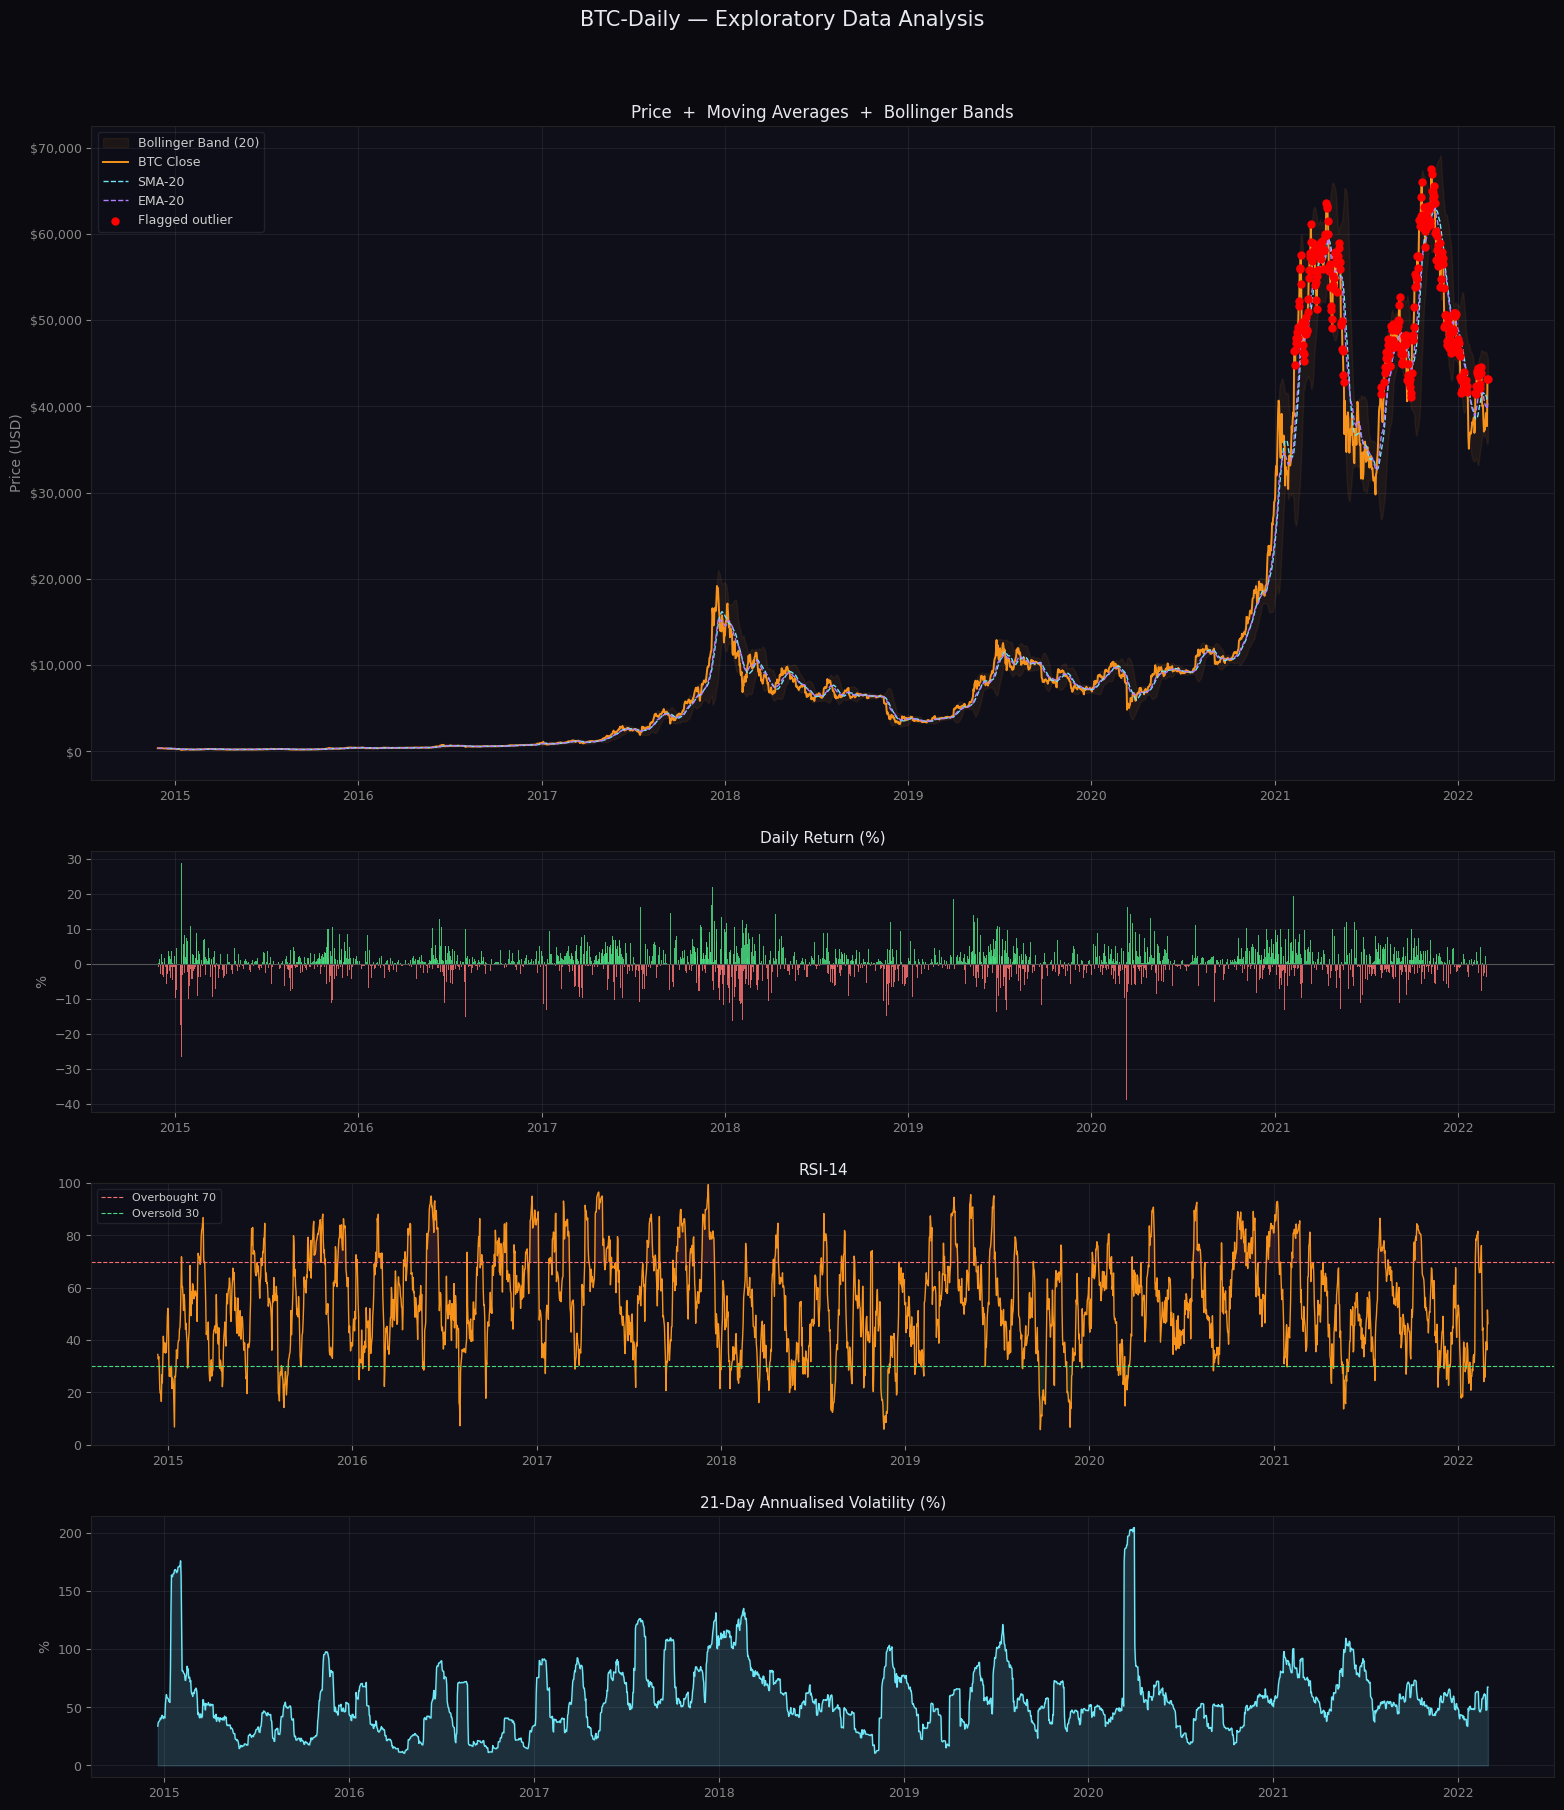

Saved -> C:\Users\youss\OneDrive\Desktop\Time_Series_Project\dataseteda_overview.png


In [ ]:
plt.style.use('dark_background')
BTC_ORANGE = '#f7931a'
OUTPUT_DIR = r'C:\Users\youss\OneDrive\Desktop\Time_Series_Project'

fig, axes = plt.subplots(4, 1, figsize=(16, 18),
                         gridspec_kw={'height_ratios': [3, 1.2, 1.2, 1.2]})
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('BTC-Daily — Exploratory Data Analysis',
             color='#e8e8f0', fontsize=15, y=1.01)

for ax in axes:
    ax.set_facecolor('#0f0f1a')
    ax.spines[['top','right','left','bottom']].set_color('#222')
    ax.tick_params(colors='#888', labelsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(alpha=0.07)

x = df['ds']

# Panel 1: Price + Bollinger Bands + Moving Averages
ax = axes[0]
ax.fill_between(x, df['BB_lower'], df['BB_upper'],
                color=BTC_ORANGE, alpha=0.07, label='Bollinger Band (20)')
ax.plot(x, df['y'],                 color=BTC_ORANGE, lw=1.4, label='BTC Close')
ax.plot(x, df[f'SMA_{SMA_WINDOW}'], color='#6ee7f7',  lw=1.0,
        linestyle='--', label=f'SMA-{SMA_WINDOW}')
ax.plot(x, df[f'EMA_{EMA_WINDOW}'], color='#b47fff',  lw=1.0,
        linestyle='--', label=f'EMA-{EMA_WINDOW}')
out = df[df['is_outlier'] == 1]
if len(out):
    ax.scatter(out['ds'], out['y'], color='red', s=25,
               zorder=5, label='Flagged outlier')
ax.set_title('Price  +  Moving Averages  +  Bollinger Bands',
             color='#e8e8f0', fontsize=12)
ax.set_ylabel('Price (USD)', color='#888')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(loc='upper left', framealpha=0.1, fontsize=9, labelcolor='#ccc')

# Panel 2: Daily Return bars
ax = axes[1]
pos = df['daily_return'] >= 0
ax.bar(x[pos],  df['daily_return'][pos],  color='#4ade80', width=1.5, alpha=0.85)
ax.bar(x[~pos], df['daily_return'][~pos], color='#f87171', width=1.5, alpha=0.85)
ax.axhline(0, color='#555', lw=0.8)
ax.set_title('Daily Return (%)', color='#e8e8f0', fontsize=11)
ax.set_ylabel('%', color='#888')

# Panel 3: RSI
ax = axes[2]
ax.plot(x, df['RSI'], color=BTC_ORANGE, lw=1)
ax.axhline(70, color='#f87171', lw=0.8, linestyle='--', label='Overbought 70')
ax.axhline(30, color='#4ade80', lw=0.8, linestyle='--', label='Oversold 30')
ax.fill_between(x, df['RSI'], 70, where=(df['RSI'] >= 70),
                color='#f87171', alpha=0.12)
ax.fill_between(x, df['RSI'], 30, where=(df['RSI'] <= 30),
                color='#4ade80', alpha=0.12)
ax.set_ylim(0, 100)
ax.set_title(f'RSI-{RSI_WINDOW}', color='#e8e8f0', fontsize=11)
ax.legend(loc='upper left', framealpha=0.1, fontsize=8, labelcolor='#ccc')

# Panel 4: Rolling Volatility
ax = axes[3]
ax.plot(x, df['volatility_21d'], color='#6ee7f7', lw=1)
ax.fill_between(x, df['volatility_21d'], alpha=0.15, color='#6ee7f7')
ax.set_title('21-Day Annualised Volatility (%)', color='#e8e8f0', fontsize=11)
ax.set_ylabel('%', color='#888')

plt.tight_layout(pad=2.0)
eda_path = OUTPUT_DIR + 'eda_overview.png'
plt.savefig(eda_path, dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print(f'Saved -> {eda_path}')

## Some Statistics

In [50]:
stat_cols = ['y', 'open', 'high', 'low',
             'Volume BTC', "Volume USD",
             'daily_return', 'log_return', 'volatility_21d', 'RSI']
stat_cols = [c for c in stat_cols if c in df.columns]  # keep only what exists

stats = df[stat_cols].describe().round(4)
stats.loc['skewness'] = df[stat_cols].skew().round(4)
stats.loc['kurtosis'] = df[stat_cols].kurt().round(4)
stats

,y,open,high,low,Volume BTC,Volume USD,daily_return,log_return,volatility_21d,RSI
count,2651.0000,2651.0000,2651.0000,2651.0000,2.651000e+03,2.651000e+03,2650.0000,2650.0000,2630.0000,2637.0000
mean,11709.3262,11693.1893,12038.5629,11296.5395,1.330041e+07,6.099369e+07,0.2593,0.0018,56.6412,54.3650
std,16282.9087,16272.5547,16739.2370,15718.2975,4.715366e+07,1.072838e+08,3.9853,0.0402,29.2499,18.4795
min,162.0000,162.0000,212.8400,152.4000,0.000000e+00,0.000000e+00,-38.9801,-0.4940,10.3528,5.7851
25%,654.3700,654.6800,664.4600,640.0500,5.357883e+03,9.516170e+03,-1.2726,-0.0128,38.5735,40.4481
50%,6407.7700,6408.9500,6540.0000,6312.0000,1.503310e+04,2.288982e+07,0.1729,0.0017,51.9783,54.1462
75%,10726.4250,10708.6200,10956.2400,10303.7550,3.435336e+06,8.018383e+07,1.8612,0.0184,71.2291,67.7269
max,67559.0000,67547.4900,69000.0000,66250.0000,7.723295e+08,1.446125e+09,28.8951,0.2538,204.7720,99.4926
skewness,1.7909,1.7943,1.7829,1.8052,6.311300e+00,4.237400e+00,-0.1124,-0.8581,1.5207,0.0355
kurtosis,1.9911,2.0053,1.9459,2.0632,5.527200e+01,2.971730e+01,8.4161,13.2461,4.3329,-0.6484


## More Visualizations

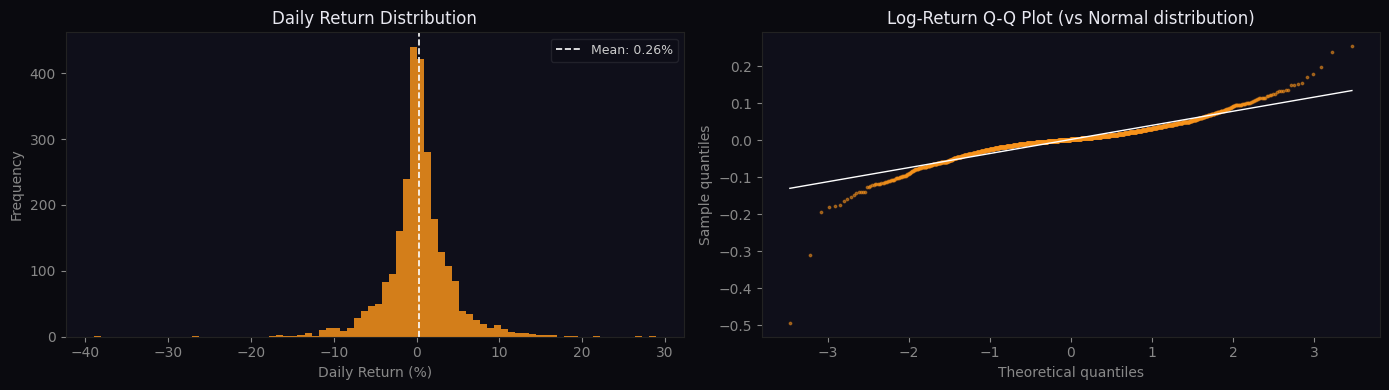

Daily return  — mean: 0.259%  std: 3.985%
Skewness : -0.112   (negative = left tail = crash risk)
Kurtosis : 8.416   (>3 = fat tails = extreme moves likely)


In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0a0a0f')
for ax in (ax1, ax2):
    ax.set_facecolor('#0f0f1a')
    ax.spines[['top','right','left','bottom']].set_color('#222')
    ax.tick_params(colors='#888')

# Histogram
ret = df['daily_return'].dropna()
ax1.hist(ret, bins=80, color=BTC_ORANGE, alpha=0.85, edgecolor='none')
ax1.axvline(ret.mean(), color='white', lw=1.2, linestyle='--',
            label=f'Mean: {ret.mean():.2f}%')
ax1.set_title('Daily Return Distribution', color='#e8e8f0')
ax1.set_xlabel('Daily Return (%)', color='#888')
ax1.set_ylabel('Frequency', color='#888')
ax1.legend(fontsize=9, labelcolor='#ccc', framealpha=0.1)

# Q-Q plot (log returns vs Normal)
log_ret = df['log_return'].dropna()
(osm, osr), (slope, intercept, _) = sp_stats.probplot(log_ret, dist='norm')
ax2.scatter(osm, osr, color=BTC_ORANGE, s=3, alpha=0.5)
ax2.plot(osm, slope * np.array(osm) + intercept, color='white', lw=1)
ax2.set_title('Log-Return Q-Q Plot (vs Normal distribution)', color='#e8e8f0')
ax2.set_xlabel('Theoretical quantiles', color='#888')
ax2.set_ylabel('Sample quantiles', color='#888')

plt.tight_layout()
dist_path = OUTPUT_DIR + 'return_distribution.png'
plt.savefig(dist_path, dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

print(f'Daily return  — mean: {ret.mean():.3f}%  std: {ret.std():.3f}%')
print(f'Skewness : {ret.skew():.3f}   (negative = left tail = crash risk)')
print(f'Kurtosis : {ret.kurt():.3f}   (>3 = fat tails = extreme moves likely)')

## 12 — Column Reference

| Column | Source | Description |
|--------|--------|-------------|
| `ds` | `date` (renamed) | Daily datestamp — Prophet-compatible |
| `y` | `close` (renamed) | Closing price USD — forecast target |
| `unix` | raw | Unix timestamp (kept for reference) |
| `symbol` | raw | Trading pair — `BTC/USD` |
| `open` | raw | Opening price (USD) |
| `high` | raw | Daily high (USD) |
| `low` | raw | Daily low (USD) |
| `Volume BTC` | raw | Trading volume in BTC |
| `Volume USD` | raw | Trading volume in USD |
| `SMA_20` | engineered | 20-day Simple Moving Average |
| `EMA_20` | engineered | 20-day Exponential Moving Average |
| `BB_upper / BB_mid / BB_lower` | engineered | 20-day Bollinger Bands (±2σ) |
| `RSI` | engineered | 14-day Relative Strength Index (0-100) |
| `daily_return` | engineered | Day-over-day % price change |
| `log_return` | engineered | Natural log return |
| `volatility_21d` | engineered | 21-day rolling annualised volatility (%) |
| `is_outlier` | engineered | 1 if price outside 3×IQR fence, else 0 |

---
**Run next:** `streamlit run app.py`